In [ ]:
%reset -f

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from tqdm import tqdm

Data Loading

In [2]:
dataset = pd.read_parquet('../../TabulatedData/values_v6_16bit.parquet')
X = dataset.drop("name", axis=1)
y = dataset["name"]
le = LabelEncoder()
y = le.fit_transform(y)
print("Data Loaded")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
del dataset, X, y

Data Loaded


Clustering

100%|██████████| 20/20 [02:20<00:00,  7.00s/it]


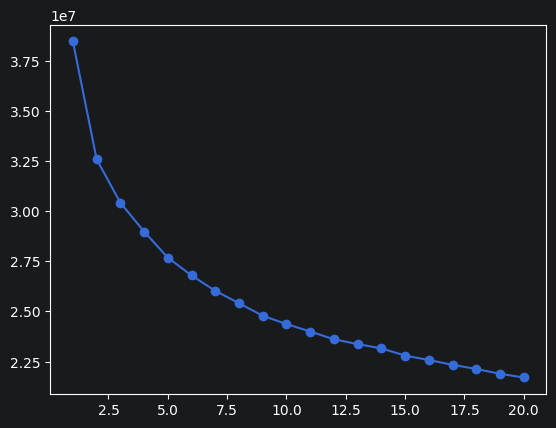

In [4]:
k_range = range(1, 21)
wcss = []

for k in tqdm(k_range):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

plt.plot(k_range, wcss, marker='o')
plt.show()